In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/annotations.xml
/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/receipts.csv
/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/boxes/11.png
/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/boxes/4.png
/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/boxes/9.png
/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/boxes/14.png
/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/boxes/1.png
/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/boxes/2.png
/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/boxes/10.png
/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/boxes/18.png
/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/boxes/12.png
/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/boxes/7.png
/kaggle/input/datasets/trainingdatapro/ocr

In [2]:
pip install --upgrade transformers accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 86.8 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.5/645.5 kB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 94.5 MB/s eta 0:00:00:00:01
Note: you may need to restart the kernel to use updated packages.


In [3]:
import kagglehub
import torch
from transformers import AutoProcessor, AutoModelForCausalLM, AutoModelForMultimodalLM

MODEL_PATH = kagglehub.model_download("google/gemma-4/transformers/gemma-4-e4b-it")


# Load model
#音声を扱うためAutoModelForMultimodalLMを使用する
#->これを選択すれば、推論時間が長くなる
processor = AutoProcessor.from_pretrained(MODEL_PATH)
model =AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    dtype="auto", #torch_dtype=torch.bfloat16  or dtype="auto"
    device_map="auto" # or "auto" or "None" or "cuda" 
)
   

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

In [4]:
import os

root_path = "/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection"

print("=== Top-level contents ===")
for item in os.listdir(root_path):
    print(item)

=== Top-level contents ===
boxes
images
annotations.xml
receipts.csv


image_1: /kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/images/0.jpg


(np.float64(-0.5), np.float64(611.5), np.float64(1022.5), np.float64(-0.5))

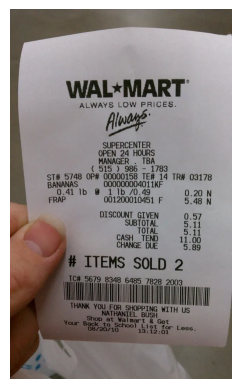

In [5]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# フォルダパス
image_dir = Path("/kaggle/input/datasets/trainingdatapro/ocr-receipts-text-detection/images")

# 画像ファイル一覧を取得（拡張子対応）
image_files = sorted(
    list(image_dir.glob("*.png")) +
    list(image_dir.glob("*.jpg")) +
    list(image_dir.glob("*.jpeg"))
)

# 一番上の画像を取得
image_1 = image_files[0]

print("image_1:", image_1)

# 画像読み込み & 表示
image_1 = Image.open(image_1)

plt.imshow(image_1)
plt.axis("off")

In [6]:
import torch
from transformers import GenerationConfig
import time

# =========================
# 1. OCR用プロンプト
# =========================
user_prompt = (
    "Please answer in Japanese. "
    "Perform OCR on this receipt image. "
    "Extract and output all readable text as accurately as possible. "
    "If some parts are unclear, say they are unclear."
)

# =========================
# 2. Gemma4 用のマルチモーダル chat 形式
# =========================
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image_1},
            {"type": "text", "text": user_prompt},
        ],
    }
]

# =========================
# 3. chat template を適用
# =========================
chat_text = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=False,
)

# =========================
# 4. 入力作成
# =========================
inputs = processor(
    text=chat_text,
    images=[image_1],
    return_tensors="pt",
)

# 必要ならGPUへ
if torch.cuda.is_available():
    inputs = {
        k: v.to(model.device) if hasattr(v, "to") else v
        for k, v in inputs.items()
    }

# =========================
# 5. 生成設定
# =========================
gen_config = GenerationConfig(
    max_new_tokens=512,
    do_sample=False,
    temperature=1.0,
)

model.eval()

# =========================
# 6. 推論
# =========================
start_time = time.time()

with torch.no_grad():
    output_ids = model.generate(
        **inputs,
        generation_config=gen_config
    )

end_time = time.time()
inference_time = end_time - start_time

# =========================
# 7. デコード
# =========================
generated_text = processor.batch_decode(
    output_ids,
    skip_special_tokens=True,
)[0]

print("=== Prompt ===")
print(user_prompt)

print("\n=== Gemma4 OCR Result ===")
print(generated_text)

print("\n=== Inference Time ===")
print(f"{inference_time:.4f} seconds")

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


=== Prompt ===
Please answer in Japanese. Perform OCR on this receipt image. Extract and output all readable text as accurately as possible. If some parts are unclear, say they are unclear.

=== Gemma4 OCR Result ===
user




Please answer in Japanese. Perform OCR on this receipt image. Extract and output all readable text as accurately as possible. If some parts are unclear, say they are unclear.
model
はい、承知いたしました。レシートの画像からOCRを実行し、読み取れるテキストを日本語で出力します。

---

**OCR結果（日本語訳とそのままのテキスト）**

**【そのままのテキスト】**
WAL*MART
ALWAYS LOW PRICES.
Always.

SUPERCENTER
OPEN 24 HOURS
MANAGER TBA

( 515 ) 986 - 1783

ST# 5748 OP# 00000158 TE# 14 TR# 03178
BANANAS
0.41 lb 0 1 lb / 0.49
FRAP 001200010451 F
DISCOUNT GIVEN 0.57
SUBTOTAL 5.11
TOTAL 5.11
CASH TEND 11.00
CHANGE DUE 5.89

\# ITEMS SOLD 2

TC# 5679 8348 6485 7828 2003

THANK YOU FOR SHOPPING WITH US
NATHANIEL BUSH
Shop at Walmart & Get
Your Back to School List for Less.
08/20/10 13:12:01

**【日本語での読み取りと解釈】**

ウォルマート
いつでも低価格。
いつも。

スーパーセンター
24時間営業
マネージ